In [ ]:
!pip install -q torch-geometric ogb streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 64.0 MB/s eta 0:00:00


In [ ]:
import os
# Compatibility fix for trusted PyG objects downloaded by the official OGB package on PyTorch 2.6+.
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/OGBN_Arxiv_Project')
RESULTS_ROOT = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

for folder in [PROJECT_ROOT, RESULTS_ROOT, MODELS_DIR, SRC_DIR, ARTIFACTS_DIR,
               PROJECT_ROOT / 'notebooks', PROJECT_ROOT / 'visualizations',
               PROJECT_ROOT / 'dashboard', PROJECT_ROOT / 'report',
               PROJECT_ROOT / 'presentation', PROJECT_ROOT / 'video']:
    folder.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/OGBN_Arxiv_Project


In [ ]:
import random
import numpy as np

# Common reproducibility settings
import warnings

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# Libraries required for Task 02
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.utils import degree

sns.set_theme(style='whitegrid')

# Load the required OGBN-Arxiv graph
dataset = PygNodePropPredDataset(
    name='ogbn-arxiv',
    root=str(PROJECT_ROOT / 'data')
)
data = dataset[0]
x_original = data.x.float()
y = data.y.view(-1).long()
edge_index_directed = data.edge_index.long()

N = data.num_nodes
E = data.num_edges
F_DIM = data.num_features
NUM_CLASSES = dataset.num_classes

print(f'Nodes: {N:,}')
print(f'Directed edges: {E:,}')
print('Features per node:', F_DIM)
print('Classes:', NUM_CLASSES)

OUTPUT = RESULTS_ROOT / 'task02_graph_analysis'
OUTPUT.mkdir(parents=True, exist_ok=True)

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:21<00:00,  3.73it/s]


Extracting /content/drive/MyDrive/OGBN_Arxiv_Project/data/arxiv.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 8112.77it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 329.02it/s]

Saving...


Nodes: 169,343
Directed edges: 1,166,243
Features per node: 128
Classes: 40


Done!


## 2.1 Graph Meaning and Node Features

Each node is a scientific paper. Each directed edge (source, target) means that the source paper cites the target paper. Each node has 128 numerical features generated from its title and abstract. These dimensions are embeddings rather than directly named words or topics.

## 2.2 Edge-List Representation and Node Features

Represents each directed citation as a source–target pair and summarizes the dimensions and numerical characteristics of the node-feature matrix.

In [ ]:
# Edge-list representation
edge_list_sample = pd.DataFrame(
    edge_index_directed[:, :1000].t().numpy(),
    columns=['source_paper', 'target_paper']
)
display(edge_list_sample.head(20))
edge_list_sample.to_csv(OUTPUT / 'sample_edge_list.csv', index=False)

# Feature description
feature_summary = pd.DataFrame({
    'statistic': ['shape', 'dtype', 'mean', 'standard deviation', 'minimum', 'maximum', 'missing values'],
    'value': [str(tuple(x_original.shape)), str(x_original.dtype), x_original.mean().item(),
              x_original.std().item(), x_original.min().item(), x_original.max().item(),
              int(torch.isnan(x_original).sum())]
})
display(feature_summary)
feature_summary.to_csv(OUTPUT / 'feature_summary.csv', index=False)

,source_paper,target_paper
0,104447,13091
1,15858,47283
2,107156,69161
3,107156,136440
4,107156,107366
5,107156,158460
6,141536,90124
7,141536,121740
8,141536,122427
9,141536,161023


,statistic,value
0,shape,"(169343, 128)"
1,dtype,torch.float32
2,mean,0.020484
3,standard deviation,0.233224
4,minimum,-1.388865
5,maximum,1.638744
6,missing values,0


## 2.3 Degree Distribution Analysis

Calculates in-degree and out-degree for every paper and visualizes their long-tailed distributions on logarithmic axes.

,measure,in_degree,out_degree
0,mean,6.886868,6.886868
1,median,1.000000,4.000000
2,maximum,13155.000000,436.000000
3,zero-degree nodes,62006.000000,17440.000000


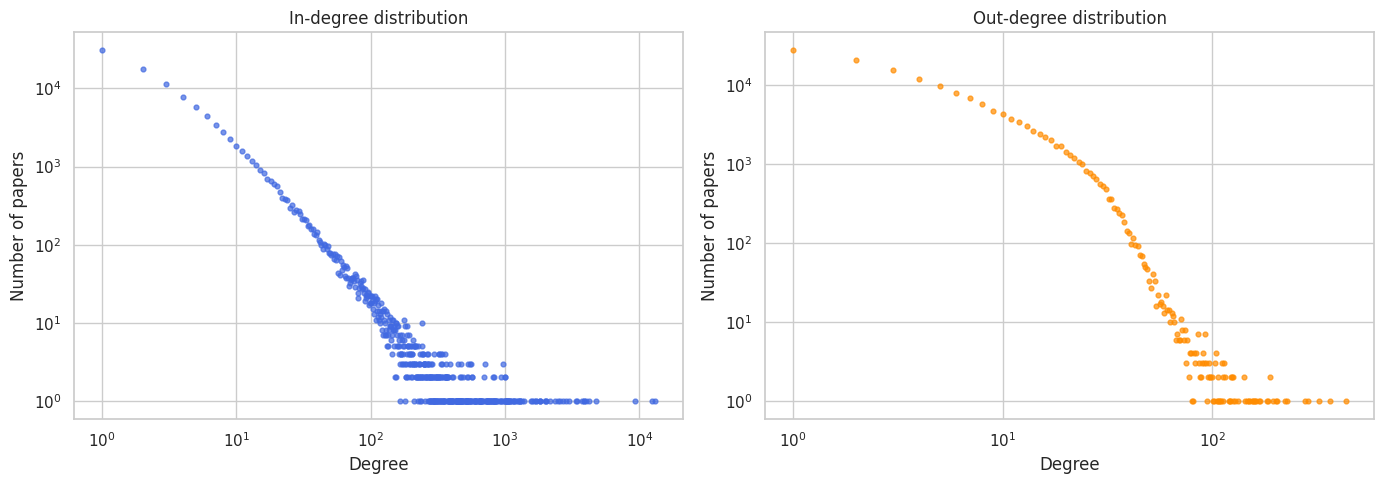

In [ ]:
# Directed degree analysis
source, target = edge_index_directed
in_degree = degree(target, N, dtype=torch.long)
out_degree = degree(source, N, dtype=torch.long)
total_degree = in_degree + out_degree

degree_summary = pd.DataFrame({
    'measure': ['mean', 'median', 'maximum', 'zero-degree nodes'],
    'in_degree': [in_degree.float().mean().item(), in_degree.median().item(), in_degree.max().item(), int((in_degree == 0).sum())],
    'out_degree': [out_degree.float().mean().item(), out_degree.median().item(), out_degree.max().item(), int((out_degree == 0).sum())]
})
display(degree_summary)
degree_summary.to_csv(OUTPUT / 'degree_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, values, title, color in [
    (axes[0], in_degree, 'In-degree distribution', 'royalblue'),
    (axes[1], out_degree, 'Out-degree distribution', 'darkorange')]:
    counts = torch.bincount(values)
    degrees = torch.arange(len(counts))
    mask = (degrees > 0) & (counts > 0)
    ax.scatter(degrees[mask], counts[mask], s=12, alpha=.7, color=color)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(title); ax.set_xlabel('Degree'); ax.set_ylabel('Number of papers')
plt.tight_layout(); plt.savefig(OUTPUT / 'degree_distribution.png', dpi=250); plt.show()

## 2.4 Graph Density and Connected Components

Measures how sparse the citation network is and identifies weakly and strongly connected regions while respecting the graph's direction where appropriate.

In [ ]:
# Directed graph density: E / [N(N-1)]
graph_density = E / (N * (N - 1))
print(f'Graph density: {graph_density:.10f}')
print(f'Density percentage: {graph_density * 100:.8f}%')

# Sparse connected-component analysis
adjacency = coo_matrix(
    (np.ones(E, dtype=np.int8), (source.numpy(), target.numpy())),
    shape=(N, N)
).tocsr()

weak_count, weak_labels = connected_components(adjacency, directed=True, connection='weak')
strong_count, strong_labels = connected_components(adjacency, directed=True, connection='strong')
weak_sizes = np.bincount(weak_labels)
strong_sizes = np.bincount(strong_labels)

component_summary = pd.DataFrame({
    'component_type': ['weak', 'strong'],
    'number_of_components': [weak_count, strong_count],
    'largest_component': [weak_sizes.max(), strong_sizes.max()]
})
display(component_summary)
component_summary.to_csv(OUTPUT / 'component_summary.csv', index=False)

Graph density: 0.0000406684
Density percentage: 0.00406684%


,component_type,number_of_components,largest_component
0,weak,1,169343
1,strong,141223,23164


## 2.5 Sample Subgraph Visualization

Selects a manageable group of connected papers and draws their citation relationships so the local graph structure can be inspected visually.

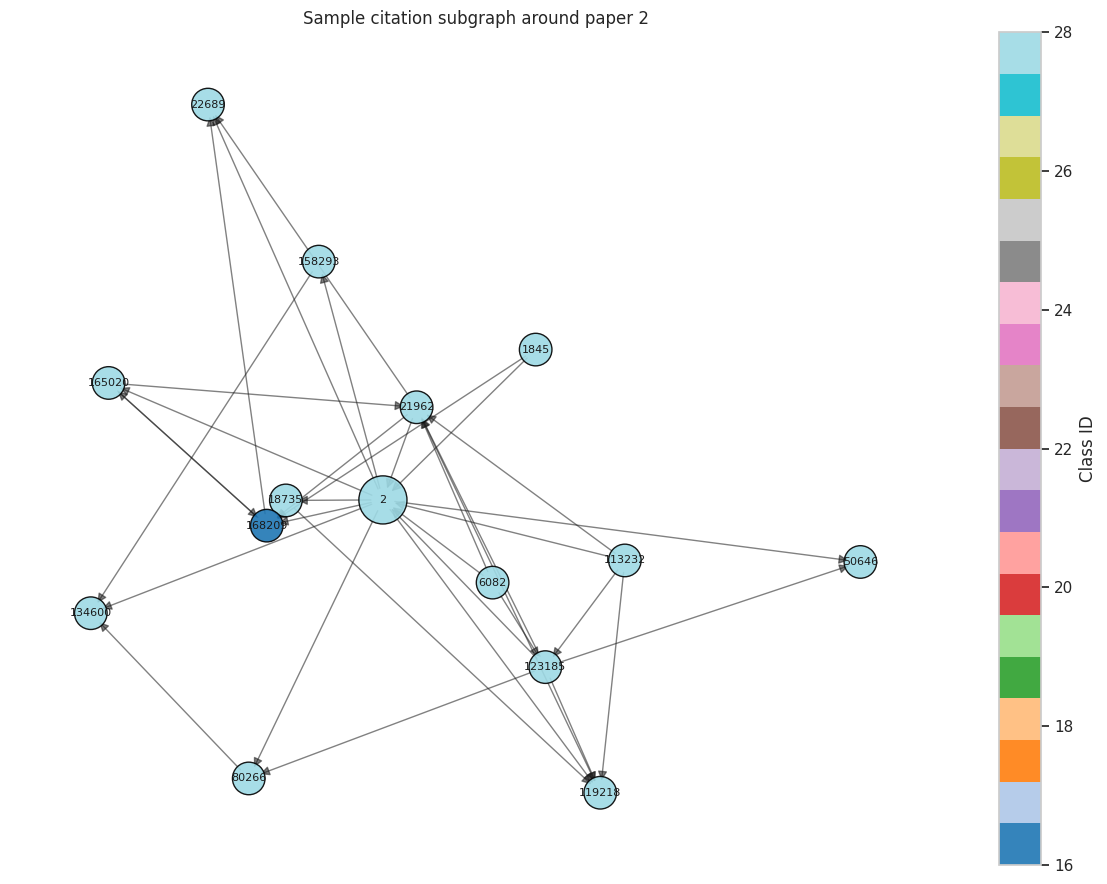

In [ ]:
# Visualize a small one-hop subgraph around a moderately connected node
candidates = torch.where((total_degree >= 8) & (total_degree <= 20))[0]
center_node = int(candidates[0]) if len(candidates) else int(torch.argmax(total_degree))
incoming = source[target == center_node].unique()
outgoing = target[source == center_node].unique()
neighbors = torch.cat([incoming, outgoing]).unique()[:30]
selected_nodes = torch.cat([torch.tensor([center_node]), neighbors]).unique()
mask = torch.isin(source, selected_nodes) & torch.isin(target, selected_nodes)
sub_edges = edge_index_directed[:, mask]

G = nx.DiGraph()
for node in selected_nodes.tolist(): G.add_node(node, label=int(y[node]))
for s, t in sub_edges.t().tolist(): G.add_edge(s, t)

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=SEED, k=1.1)
colors = [G.nodes[n]['label'] for n in G.nodes]
sizes = [1200 if n == center_node else 550 for n in G.nodes]
nodes = nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes,
                               cmap='tab20', edgecolors='black', alpha=.9)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=14, alpha=.55)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.colorbar(nodes, label='Class ID'); plt.title(f'Sample citation subgraph around paper {center_node}')
plt.axis('off'); plt.tight_layout(); plt.savefig(OUTPUT / 'sample_subgraph.png', dpi=250); plt.show()

## 2.6 Structural Interpretation

Citation counts are long-tailed: most papers have relatively few links, while a small number are highly connected. The very low density shows that the network is sparse. Weak components ignore direction, whereas strong components require mutually reachable directed paths.

## 2.7 Saving Graph Statistics

Stores the calculated graph-level statistics in a structured table for later reporting and dashboard use.

In [ ]:
graph_statistics = {
    'nodes': N, 'edges': E, 'features': F_DIM, 'classes': NUM_CLASSES,
    'density': graph_density, 'weak_components': int(weak_count),
    'strong_components': int(strong_count)
}
(OUTPUT / 'graph_statistics.json').write_text(json.dumps(graph_statistics, indent=2))
print('Saved graph statistics for the dashboard.')

Saved graph statistics for the dashboard.
